In [1]:
# import modules
%matplotlib inline 

import matplotlib.pyplot as plt #module for making a graph
import numpy as np #module for numerical operations
import sympy  #module for simbolic mathematic expressions
from scipy import integrate # module to solve diferential equations

# print with mathematical expressions
sympy.init_printing(use_latex='mathjax')

R=8.314

# PFR constant Pressure

The reaction transforms A -> B

In gas state. And the system is represented by and system of diferential equation
x
 $$ \frac {dx}{dV}= -\frac{r_rx}{MFlow} $$

 $$ \frac {dT}{dV}= \frac {(r_rx* \Delta H+U*a*(Ta-T))} {sumFCp} $$

In [2]:
#Class of reagent, the class has the parameters of the substance
class GasReagent:
    state = 'Ideal gas'
    
    def __init__(self,ID:str, Deltarx:float, Cp:float, Arrhenius:float,Ea_Arrhenius:float):
        self.ID=ID
        self.Deltarx= Deltarx #Reaction enthalpy       
        self.Cp= Cp           #Heat capacity
        self.Arrhen= Arrhenius
        self.Ea= Ea_Arrhenius

        if Cp<=0:
            raise ValueError("Invalid value, heat capacity has to be positive number")
        if Arrhenius<=0:
            raise ValueError("Invalid value, pre-exponential factor of Arrhenius equation has to be positive number")
        if Ea_Arrhenius<=0:
            raise ValueError("Invalid value, Activation energy has to be positive number")
        
    def DisplayGasReagent(self):
        return print(f"Ideal gas: {self.ID} \nReaction enthalpy= {self.Deltarx:1.0f} J/mol \nHeat Capacity Cp= {self.Cp:1.0f} J/mol \nArrhenius parameter= {self.Arrhen:.3e} \nActivation energy= {self.Ea:.3e} J/mol")
    def Krx_T(self,T):
        return self.Arrhen*np.exp(-self.Ea/(R*T)) #Arrhenius equation
    def ReagentValidation(self):
        return print
    
TestReagent = GasReagent('test',-87150,525,2.511*(10**14),121000)

print(TestReagent.DisplayGasReagent()) #test of the function of GasReagent class

#print(f"factor of chemical rate {TestReagent.Krx_T(433)}") #test of Arrhenius equation

#Class of the equipment, PFR unit with the description of the reactor
class PFRunit:
    def __init__(self,ID:str, To:float , Ta:float, ConcI:float, MFlow:float, D:float, U:float):
        self.ID= ID
        self.To= To
        self.Ta= Ta
        self.ConcI= ConcI
        self.MFlow= MFlow
        self.D= D
        self.U= U

        if To<=0:
            raise ValueError("Invalid value, Initial temperature has to be positive number")
        if Ta<=0:
            raise ValueError("Invalid value, Temperature of the jacket has to be positive number")
        if ConcI<=0:
            raise ValueError("Invalid value, Initial concentration has to be positive number")
        if MFlow<=0:
            raise ValueError("Invalid value, molecular flow has to be positive number")
        if D<=0:
            raise ValueError("Invalid value, Diameter of the reactor has to be positive number")
        if U<=0:
            raise ValueError("Invalid value, Constant of heat transfer has to be positive number")
    
    def DisplayPFR(self):
        return print(f"PFR unit: {self.ID} \nInitial temperature= {self.To:1.0f} K \nTemperature of jacket= {self.Ta:1.0f} K \nInitial Concentration= {self.ConcI:1.0f} mol/m3 \nMolar Flow= {self.MFlow:.3e} mol/h")
    def a(self):
        return 4/self.D

    
TestPFR = PFRunit('test',433,433,3600, 590, 0.1016, 8.36*10**5) 

#Class with the solution of the equation
class PFRsol:
    
    def __init__(self,ID, V , sol):
        self.ID= ID
        self.V= V #volume of the reactor, it is considered the independet variable
        self.sol= sol #Will be an array with the data (conversion of the reagent and temperature)

#system of equation, the volume is the independent variable and the output is conversion (x) and temperature (T)
def sistEqPFR(x_T, Volume, GasReagent, PFRunit):
    x,T=x_T   
    sumFCp= GasReagent.Cp*PFRunit.MFlow
    krx= GasReagent.Krx_T(T)
    Conc= PFRunit.ConcI*(1-x)*PFRunit.To/T
    r_rx=-krx*Conc

    dxdV= -r_rx/PFRunit.MFlow # 1st diferential equation

    Deltarx=GasReagent.Deltarx
    U= PFRunit.U
    a=PFRunit.a()
    Ta= PFRunit.Ta
    
    dTdv= (r_rx*Deltarx+U*a*(Ta-T))/sumFCp # 2do diferential equation
    difdV = [dxdV,dTdv]

    return difdV 



def solPFR(EstVol, GasReagent, PFRunit): #function that solves the system of diferential equation. it returns an object "PFRsol", 
    
    if EstVol<=0:
            raise ValueError("Invalid value, Estimated volume has to be positive number")
    
    ic=[0,PFRunit.To]
    Volume=np.linspace(0,EstVol,1000)
    
    sol=integrate.odeint(sistEqPFR,ic,Volume,args=(GasReagent,PFRunit))
    IDPFR= f'Reagent({GasReagent.ID}) with PFR unit ({PFRunit.ID})'
    PFRobject = PFRsol(IDPFR,Volume,sol)
    return PFRobject
    


#print(sistEqPFR([0.00,433],0 ,TestReagent ,TestPFR)) #test of the use of diferential equation system

#testsol=solPFR(1,TestReagent,TestPFR)


#Plot
def plotPFR(PFRsol):
    IDReagent= PFRsol.ID
    V= PFRsol.V
    x= PFRsol.sol[:,0] #values in sol are assigned to variables to make a graph, conversion values and temperature values
    T= PFRsol.sol[:,1]
    
    fig, ax1 = plt.subplots() 

    color = 'tab:gray'
    ax1.set_xlabel('Volume (m3)')
    ax1.set_ylabel('Conversion', color=color)
    ax1.plot(V, x, color=color)
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

    color = 'tab:red'
    ax2.set_ylabel('Temperature (K)', color=color)  # we already handled the x-label with ax1
    ax2.plot(V, T, color=color)
    ax2.tick_params(axis='y', labelcolor=color)

    fig.tight_layout()  # otherwise the right y-label is slightly clipped


    plt.title(f'{IDReagent}')
    return plt.show()

#plotPFR(testsol)
#print(f'Tmax:{np.amax(T):1.3f}K') 





Ideal gas: test 
Reaction enthalpy= -87150 J/mol 
Heat Capacity Cp= 525 J/mol 
Arrhenius parameter= 2.511e+14 
Activation energy= 1.210e+05 J/mol
None


Ideal gas: test 
Reaction enthalpy= -87150 J/mol 
Heat Capacity Cp= 525 J/mol 
Arrhenius parameter= 2.511e+14 
Activation energy= 1.210e+05 J/mol
PFR unit: test 
Initial temperature= 433 K 
Temperature of jacket= 433 K 
Initial Concentration= 3600 mol/m3 
Molar Flow= 5.900e+02 mol/h


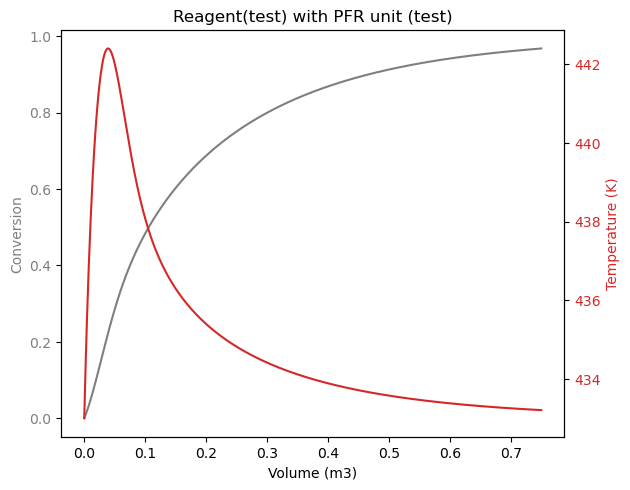

PFR unit: test0 
Initial temperature= 430 K 
Temperature of jacket= 430 K 
Initial Concentration= 4000 mol/m3 
Molar Flow= 6.000e+02 mol/h


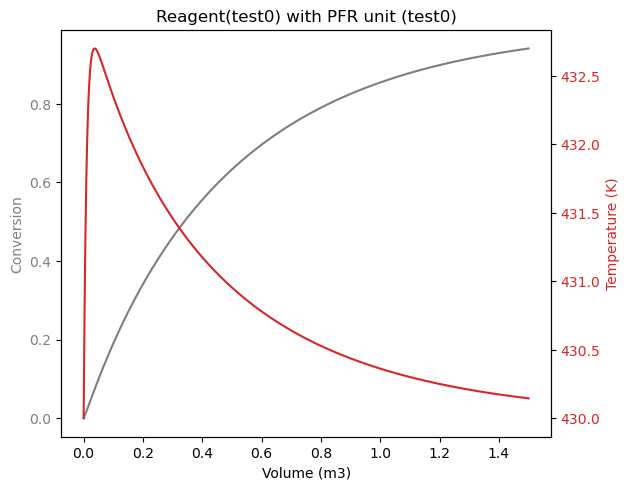

In [3]:
ReagentABC = GasReagent('test',-87150,525,2.511*(10**14),121000)
PFR_ABC = PFRunit('test',433,433,3600, 590, 0.1016, 8.36*10**5)

ReagentABC.DisplayGasReagent()
PFR_ABC.DisplayPFR()
ABC_ABC=solPFR(0.75,ReagentABC,PFR_ABC)
plotPFR(ABC_ABC)


## Second run with diferent input
Reagentzeros = GasReagent('test0',-90000,530,10**14,120000)
PFR_zero = PFRunit('test0',430,430,4000, 600, 0.1, 10**6)

Reagentzeros.DisplayGasReagent
PFR_zero.DisplayPFR()
Zerosol=solPFR(1.5,Reagentzeros,PFR_zero)
plotPFR(Zerosol)

In [ ]:
ReagentSunday = GasReagent('sunday',-10000,500,4*(10**14),130000)
PFRSunday = PFRunit('sunday',0,400,4000, 500, 0.2, 6*10**5)

ReagentSunday.DisplayGasReagent()
PFRSunday.DisplayPFR()
SolSunday=solPFR(50,ReagentSunday,PFRSunday)
plotPFR(SolSunday)